In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astroquery.vizier import Vizier
import warnings
warnings.filterwarnings('ignore')

print("imports ok")

imports ok


In [5]:
v = Vizier(columns=['PSRJ', 'P0', 'P1', 'Age', 'Bsurf', 'Dist'],
           row_limit=3000)

result = v.query_constraints(catalog='B/psr/psr')
pulsars = result[0]
print(f"Fetched {len(pulsars)} pulsars")
print(pulsars.colnames)
print(pulsars[:5])

Fetched 2536 pulsars
['PSRJ', 'P0', 'P1', 'Age', 'Bsurf', 'Dist']
    PSRJ            P0                P1             Age        Bsurf    Dist
                    s                                 yr                 kpc 
----------- ----------------- ----------------- ------------- --------- -----
 J0006+1834  0.69374767047000         2.097e-15     5240000.0   1.2e+12  0.70
 J0007+7303  0.31587319090000        3.6039e-13       13900.0   1.1e+13  1.40
 J0014+4746  1.24069903894600        5.6446e-16    34800000.0   8.5e+11  1.82
 J0023+0923  0.00305000000000                --            --        --  1.00
J0024-7204C  0.00575677999551        -4.985e-20            --        --  4.00


In [6]:
# clean the data — drop rows with missing P0 or P1
import numpy as np
import matplotlib.pyplot as plt

P0 = np.array(pulsars['P0'].filled(np.nan), dtype=float)
P1 = np.array(pulsars['P1'].filled(np.nan), dtype=float)

# keep only valid, positive P1 (negative P1 are recycled pulsars with measurement noise)
mask = np.isfinite(P0) & np.isfinite(P1) & (P1 > 0)
P0 = P0[mask]
P1 = P1[mask]

print(f"Pulsars with valid P0 and P1: {len(P0)}")
print(f"P0 range: {P0.min():.4f} to {P0.max():.2f} seconds")
print(f"P1 range: {P1.min():.2e} to {P1.max():.2e}")

Pulsars with valid P0 and P1: 2052
P0 range: 0.0016 to 11.79 seconds
P1 range: 1.17e-21 to 5.49e-10


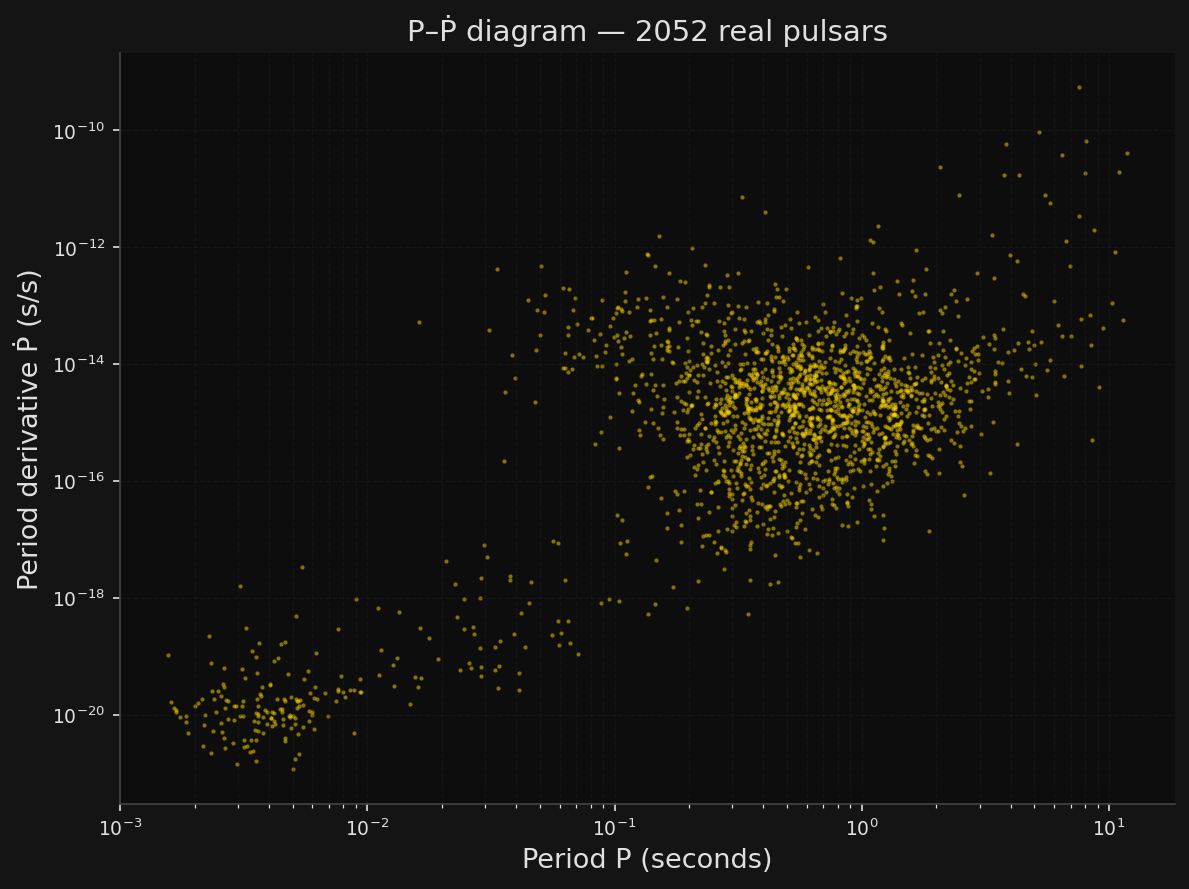

saved


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(P0, P1, s=4, alpha=0.5, color='gold', linewidths=0)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Period P (seconds)', fontsize=13)
ax.set_ylabel('Period derivative Ṗ (s/s)', fontsize=13)
ax.set_title('P–Ṗ diagram — 2052 real pulsars', fontsize=14)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ppdot.png', dpi=150)
plt.show()
print("saved")

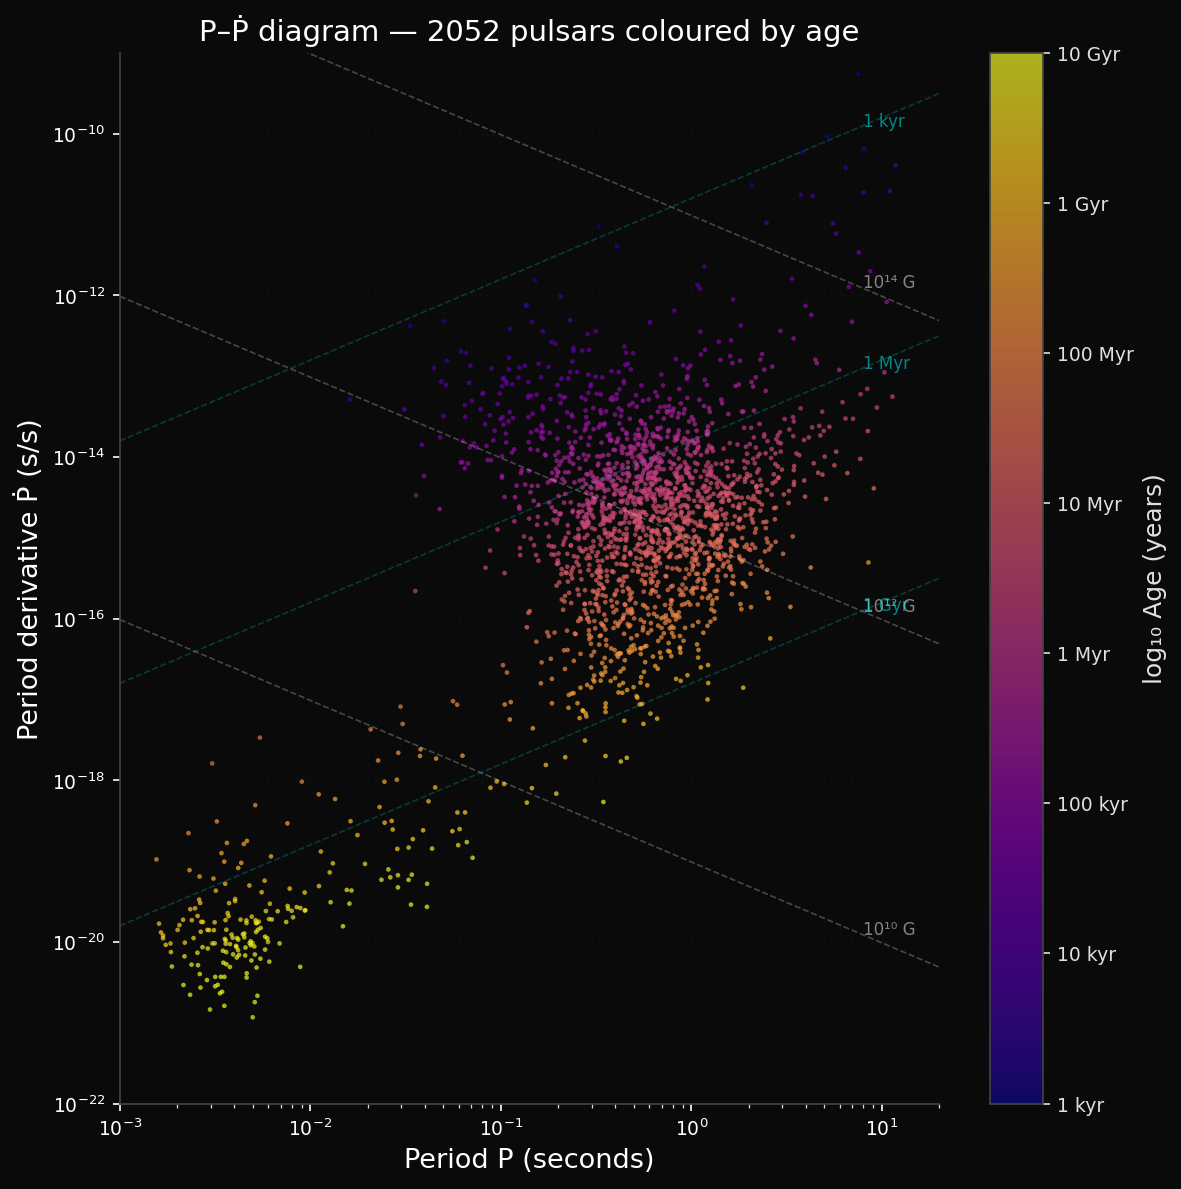

saved


In [13]:
# characteristic age: tau = P / (2 * P1) in years
tau = P0 / (2 * P1) / 3.156e7  # convert seconds to years

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(P0, P1, c=np.log10(tau), cmap='plasma',
                s=5, alpha=0.7, linewidths=0,
                vmin=3, vmax=10)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log₁₀ Age (years)', fontsize=12)
cbar.set_ticks([3, 4, 5, 6, 7, 8, 9, 10])
cbar.set_ticklabels(['1 kyr', '10 kyr', '100 kyr', '1 Myr',
                     '10 Myr', '100 Myr', '1 Gyr', '10 Gyr'])

# magnetic field lines
P_grid = np.logspace(-3, 2, 300)
for B, label in [(1e10, '10¹⁰ G'), (1e12, '10¹² G'), (1e14, '10¹⁴ G')]:
    P1_B = (B / 3.2e19)**2 / P_grid
    ax.plot(P_grid, P1_B, 'white', alpha=0.25, linewidth=0.8, linestyle='--')
    idx = np.argmin(np.abs(P_grid - 8))
    ax.text(8, P1_B[idx], label, color='white', fontsize=8, alpha=0.5)

# age lines
for tau_yr, label in [(1e3, '1 kyr'), (1e6, '1 Myr'), (1e9, '1 Gyr')]:
    tau_s = tau_yr * 3.156e7
    P1_tau = P_grid / (2 * tau_s)
    ax.plot(P_grid, P1_tau, 'cyan', alpha=0.2, linewidth=0.8, linestyle='--')
    idx = np.argmin(np.abs(P_grid - 8))
    ax.text(8, P1_tau[idx], label, color='cyan', fontsize=8, alpha=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-3, 20)
ax.set_ylim(1e-22, 1e-9)
ax.set_xlabel('Period P (seconds)', fontsize=13)
ax.set_ylabel('Period derivative Ṗ (s/s)', fontsize=13)
ax.set_title('P–Ṗ diagram — 2052 pulsars coloured by age', fontsize=14)
ax.grid(True, alpha=0.15, which='both')
ax.set_facecolor('#0a0a0a')
fig.patch.set_facecolor('#0a0a0a')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

plt.tight_layout()
plt.savefig('ppdot_coloured.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("saved")